# 01 — Data Pipeline & EDA for Taglish Sentiment Classification

**Project:** Sentiment Analysis of Taglish E-Commerce Reviews using Naive Bayes and XLM-RoBERTa

**Notebook owner:** [Your Name] (Data Person)

**Role:** Load FiReCS, produce `firecs_processed.csv`, generate EDA figures, and build phenomenon slices for comparison analysis.

**Day 1 goal:** Save `firecs_processed.csv` to unblock NB and XLM-R persons. Generate EDA plots.

**Day 2 goal:** Build phenomenon slices from the test set for linguistic error analysis.

## 0. Setup
Mount Google Drive, configure shared paths, and install dependencies.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

DRIVE_BASE     = "/content/drive/MyDrive/Machine Learning - Group 5/Finals Project/taglish-project"
DATA_TRAIN     = f"{DRIVE_BASE}/data/FiReCS_train_set.csv"
DATA_TEST      = f"{DRIVE_BASE}/data/FiReCS_test_set.csv"
DATA_PROCESSED = f"{DRIVE_BASE}/data/firecs_processed.csv"
OUTPUTS        = f"{DRIVE_BASE}/outputs"
FIGURES        = f"{DRIVE_BASE}/outputs/figures"

os.makedirs(FIGURES, exist_ok=True)
os.makedirs(OUTPUTS, exist_ok=True)

print("Paths set. Drive base:", DRIVE_BASE)

Paths set. Drive base: /content/drive/MyDrive/Machine Learning - Group 5/Finals Project/taglish-project


In [ ]:
!pip install pandas matplotlib seaborn scikit-learn -q

## 1. Load Raw Data
Load FiReCS train and test CSVs, inspect schema, label distribution, and class balance.
Expected: 7,340 train rows / 3,147 test rows, columns: `review`, `label`.

In [ ]:
import pandas as pd

train_df = pd.read_csv(DATA_TRAIN)
test_df  = pd.read_csv(DATA_TEST)

print("TRAIN shape:", train_df.shape)
print("TEST shape:", test_df.shape)
print("\nColumns:", train_df.columns.tolist())
print("\nDtypes:\n", train_df.dtypes)
print("\nTRAIN sample:")
display(train_df.head(3))
print("\nTRAIN label distribution:\n", train_df.iloc[:, -1].value_counts())
print("\nTEST label distribution:\n",  test_df.iloc[:, -1].value_counts())

TRAIN shape: (7340, 2)
TEST shape: (3147, 2)

Columns: ['review', 'label']

Dtypes:
 review     object
label     float64
dtype: object

TRAIN sample:


,review,label
0,im very disappointed kasi di gumana ang dalawa...,0.0
1,10 10 it has minor damage when it was delivere...,1.0
2,super ganda then tama ung size and color sa uu...,2.0



TRAIN label distribution:
 label
1.0    2549
2.0    2410
0.0    2381
Name: count, dtype: int64

TEST label distribution:
 label
1.0    1087
2.0    1033
0.0    1027
Name: count, dtype: int64


## 2. Label Encoding and Merge
Convert float labels to int (0=Negative, 1=Neutral, 2=Positive), add split column,
merge into one `firecs_processed.csv`. Saving this file unblocks Person 2 (NB) and Person 3 (XLM-R).

In [ ]:
# Convert labels from float to int (0.0 → 0, 1.0 → 1, 2.0 → 2)
train_df['label'] = train_df['label'].astype(int)
test_df['label']  = test_df['label'].astype(int)

# Add split column to track origin after merging
train_df['split'] = 'train'
test_df['split']  = 'test'

# Merge into one processed file
processed = pd.concat([train_df, test_df], ignore_index=True)

# Save to shared Drive folder — this unblocks Person 2
processed.to_csv(DATA_PROCESSED, index=False)

# Confirm
print(f"Saved to: {DATA_PROCESSED}")
print(f"Total rows: {len(processed)}")
print(f"\nRows per split:\n{processed['split'].value_counts()}")
print(f"\nLabel distribution (full):\n{processed['label'].value_counts().sort_index()}")

Saved to: /content/drive/MyDrive/Machine Learning - Group 5/Finals Project/taglish-project/data/firecs_processed.csv
Total rows: 10487

Rows per split:
split
train    7340
test     3147
Name: count, dtype: int64

Label distribution (full):
label
0    3408
1    3636
2    3443
Name: count, dtype: int64


## 3. EDA — Class Distribution and Review Length
Visualize class balance across train and test splits and review length distribution by class.
Figures saved to `outputs/figures/`.

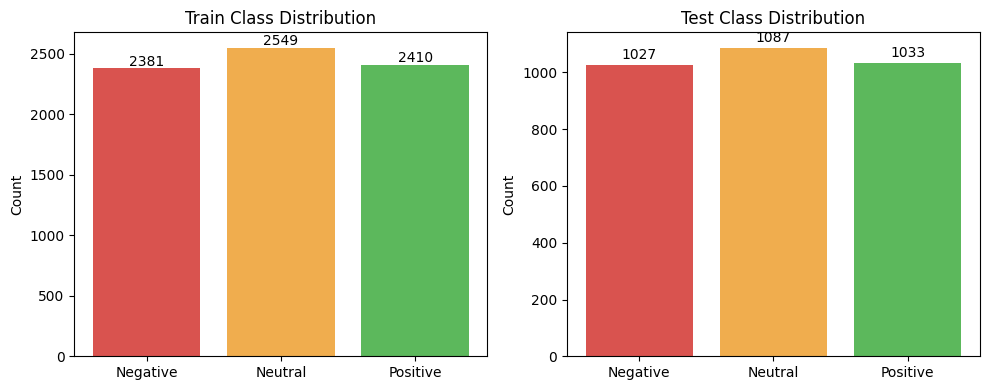

Saved: eda_class_distribution.png


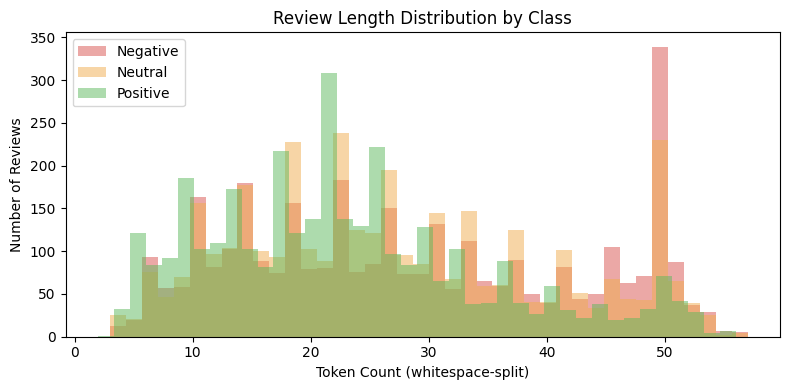

Saved: eda_length_distribution.png

Token count stats by class:
        count  mean   std  min   25%   50%   75%   max
label                                                 
0      3408.0  28.9  14.2  3.0  16.0  27.0  42.0  57.0
1      3636.0  27.1  13.0  3.0  17.0  25.0  37.0  57.0
2      3443.0  23.0  11.8  2.0  14.0  22.0  29.0  56.0


In [ ]:
import matplotlib.pyplot as plt

# --- Plot 1: Class distribution by split ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

for ax, (split_name, split_df) in zip(axes, [('Train', train_df), ('Test', test_df)]):
    counts = split_df['label'].value_counts().sort_index()
    ax.bar([label_names[i] for i in counts.index], counts.values, color=['#d9534f','#f0ad4e','#5cb85c'])
    ax.set_title(f'{split_name} Class Distribution')
    ax.set_ylabel('Count')
    # Annotate bar counts
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f"{FIGURES}/eda_class_distribution.png", dpi=150)
plt.show()
print("Saved: eda_class_distribution.png")


# --- Plot 2: Review length distribution by class ---
processed['token_count'] = processed['review'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(8, 4))
colors = {0: '#d9534f', 1: '#f0ad4e', 2: '#5cb85c'}

for label_val, label_name in label_names.items():
    subset = processed[processed['label'] == label_val]['token_count']
    ax.hist(subset, bins=40, alpha=0.5, label=label_name, color=colors[label_val])

ax.set_title('Review Length Distribution by Class')
ax.set_xlabel('Token Count (whitespace-split)')
ax.set_ylabel('Number of Reviews')
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES}/eda_length_distribution.png", dpi=150)
plt.show()
print("Saved: eda_length_distribution.png")


# --- Summary stats: token counts per class ---
print("\nToken count stats by class:")
print(processed.groupby('label')['token_count'].describe().round(1))

In [ ]:
import pandas as pd

# Load processed data and isolate test set
processed = pd.read_csv(DATA_PROCESSED)
test_df = processed[processed['split'] == 'test'].reset_index(drop=True)

# Add token count column for short/long slices
test_df['token_count'] = test_df['review'].apply(lambda x: len(str(x).split()))

print(f"Test set: {len(test_df)} rows")
print(test_df.head(3))

Test set: 3147 rows
                                              review  label split  token_count
0  okay naman kaso maliit size e adjust nyona lan...      1  test           13
1  good seller sends out photo before shipping ma...      2  test           27
2  di cya gano kabilis sa net loading and loading...      1  test           14


## 4. Phenomenon Slices (Day 2)
Filter the test set into linguistic subsets for the comparison analysis in Notebook 04.
Slices cover: pragmatic markers (naman, lang, pa, na), slang (awit), negation (hindi, di, wala),
review length (short <10 tokens, long >50 tokens), and code-switching density (high/low CS).
Saved to `outputs/phenomenon_slices.csv`.

In [ ]:
# Build phenomenon slices from test set
slices = []

# --- Pragmatic markers (individual slices per marker) ---
for marker in ['naman', 'lang', 'pa', 'na']:
    subset = test_df[test_df['review'].str.contains(rf'\b{marker}\b', regex=True)].copy()
    subset['slice_name'] = f'marker_{marker}'
    slices.append(subset)

# --- Slang ---
for slang in ['awit']:
    subset = test_df[test_df['review'].str.contains(rf'\b{slang}\b', regex=True)].copy()
    subset['slice_name'] = f'slang_{slang}'
    slices.append(subset)

# --- Negation ---
for neg in ['hindi', 'di', 'wala']:
    subset = test_df[test_df['review'].str.contains(rf'\b{neg}\b', regex=True)].copy()
    subset['slice_name'] = f'negation_{neg}'
    slices.append(subset)

# --- Review length ---
short = test_df[test_df['token_count'] < 10].copy()
short['slice_name'] = 'short_reviews'
slices.append(short)

long = test_df[test_df['token_count'] > 50].copy()
long['slice_name'] = 'long_reviews'
slices.append(long)

# --- Code-switching density ---
# Proxy: load a basic English word list, count non-English tokens as Filipino
english_words = set([
    'the','a','an','is','are','was','were','i','you','he','she','it','we','they',
    'my','your','his','her','our','their','this','that','these','those','and','or',
    'but','so','if','in','on','at','to','for','of','with','from','by','as','not',
    'have','has','had','do','does','did','be','been','being','will','would','can',
    'could','should','may','might','must','shall','very','just','also','more','good',
    'great','nice','well','bad','really','all','no','yes','ok','okay','so','get',
    'got','like','love','need','want','use','go','come','see','know','think','make',
    'order','ordered','product','item','seller','shop','shipping','delivery','quality',
    'price','size','color','color','received','recommend','highly','would','worth'
])

def cs_density(text):
    # Returns ratio of non-English tokens (proxy for Filipino tokens)
    tokens = str(text).lower().split()
    if len(tokens) == 0:
        return 0
    filipino_count = sum(1 for t in tokens if t not in english_words)
    return filipino_count / len(tokens)

test_df['cs_density'] = test_df['review'].apply(cs_density)

high_cs = test_df[test_df['cs_density'] > 0.5].copy()
high_cs['slice_name'] = 'high_cs'
slices.append(high_cs)

low_cs = test_df[test_df['cs_density'] <= 0.5].copy()
low_cs['slice_name'] = 'low_cs'
slices.append(low_cs)

# --- Combine and save ---
phenomenon_df = pd.concat(slices, ignore_index=True)
phenomenon_df = phenomenon_df[['review', 'label', 'slice_name']]
phenomenon_df.to_csv(f"{OUTPUTS}/phenomenon_slices.csv", index=False)

print(f"Saved: phenomenon_slices.csv")
print(f"\nSlice sizes:")
print(phenomenon_df['slice_name'].value_counts().sort_index())

Saved: phenomenon_slices.csv

Slice sizes:
slice_name
high_cs           3050
long_reviews       111
low_cs              97
marker_lang        899
marker_na         1427
marker_naman       765
marker_pa          554
negation_di        440
negation_hindi     543
negation_wala      213
short_reviews      256
slang_awit           5
Name: count, dtype: int64
